# Validación del Sistema de Automatización MLOps

Análisis de rendimiento, escalabilidad y robustez del sistema de ejecución paralela de pipelines MLOps.

**Convención de nombres:** `vX_YUVW`
| Campo | Significado |
|-------|-------------|
| X | Número de fase (del proyecto) |
| Y | Número de experimento (1-4) |
| U | Runner de origen (1=Local, 2=GHA, 3=K8s-8gb, 4=K8s-24gb, 5=ESP32, 6=ESP32-Virtual) |
| VW | Número secuencial de variante (01-99) |


## 0. Carga de datos y configuración

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime, timedelta

EXPORT_FIGURES = True

# Configuración visual
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Paleta de colores por runner
RUNNER_COLORS = {
    "Local":              "#636EFA",
    "GithubActions":      "#EF553B",
    "K8s-8gb":            "#00CC96",
    "K8s-24gb":           "#AB63FA",
    "ESP32-v1":           "#FFA15A",
    "ESP32-v2":           "#FFA15A",
    "ESP32-v3-virtual":   "#19D3F3",
    "ESP32-v4-virtual":   "#19D3F3",
}

RUNNER_ORDER = ["Local", "GithubActions", "K8s-8gb", "K8s-24gb", "ESP32-v1", "ESP32-v2", "ESP32-v3-virtual", "ESP32-v4-virtual"]

In [113]:
# ── Carga del dataset ──
# Reemplazar por la ruta real cuando se tengan los datos del experimento
# CSV_PATH = "ejemplo.csv"
CSV_PATH = "validacion_variants.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["created_at", "started_at", "completed_at"])

# Validación rápida
print(f"Total registros: {len(df)}")
print(f"Experimentos: {sorted(df['experiment'].unique())}")
print(f"Runners: {df['runner'].unique()}")
print(f"Fases: {df['phase'].unique()}")
print()
df.head(10)


Total registros: 84
Experimentos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Runners: <StringArray>
[         'K8s-8gb',         'K8s-24gb',    'GithubActions',
            'Local',         'ESP32-v2', 'ESP32-v4-virtual',
         'ESP32-v1', 'ESP32-v3-virtual']
Length: 8, dtype: str
Fases: <StringArray>
[ 'f01_explore',   'f02_events',  'f03_windows',  'f04_targets',
 'f05_modeling',    'f06_quant',   'f07_modval',   'f08_sysval']
Length: 8, dtype: str



,experiment,variant,phase,runner,runner_code,parent_variant,created_at,started_at,completed_at,queue_seconds,execution_seconds,total_seconds,status
0,0,v1_0004,f01_explore,K8s-8gb,3,NaN,2026-06-16 01:07:06.025025+00:00,2026-06-16 01:07:16.309134+00:00,2026-06-16 01:07:46.502963+00:00,10.0,30.0,40,failed
1,0,v1_0003,f01_explore,K8s-24gb,4,NaN,2026-06-16 01:06:16.904195+00:00,2026-06-16 01:06:21.318536+00:00,2026-06-16 01:12:09.460155+00:00,4.0,348.0,352,success
2,0,v1_0002,f01_explore,GithubActions,2,NaN,2026-06-16 01:06:12.301453+00:00,2026-06-16 01:06:22.303898+00:00,2026-06-16 01:17:14.510938+00:00,10.0,652.0,662,success
3,0,v1_0001,f01_explore,GithubActions,2,NaN,2026-06-16 01:34:03.880861+00:00,2026-06-16 01:34:14.344967+00:00,2026-06-16 01:37:19.472526+00:00,10.0,185.0,195,success
4,0,v2_0002,f02_events,GithubActions,2,v1_0001,2026-06-16 01:34:03.882501+00:00,2026-06-16 01:37:44.048721+00:00,2026-06-16 01:40:29.074603+00:00,220.0,165.0,385,success
5,0,v3_0001,f03_windows,GithubActions,2,v2_0002,2026-06-16 01:34:03.883358+00:00,2026-06-16 01:40:44.429183+00:00,2026-06-16 01:43:08.874313+00:00,400.0,144.0,544,success
6,2,v3_2301,f03_windows,K8s-8gb,3,v2_0002,2026-06-16 07:19:07.409944+00:00,2026-06-16 07:19:17.836606+00:00,2026-06-16 07:27:05.206029+00:00,10.0,467.0,477,success
7,2,v3_2302,f03_windows,K8s-8gb,3,v2_0002,2026-06-16 07:19:07.410368+00:00,2026-06-16 07:19:17.615851+00:00,2026-06-16 07:27:05.249247+00:00,10.0,467.0,477,success
8,2,v3_2303,f03_windows,K8s-8gb,3,v2_0002,2026-06-16 07:19:07.411222+00:00,2026-06-16 07:19:17.652237+00:00,2026-06-16 07:27:05.288868+00:00,10.0,467.0,477,success
9,2,v3_2305,f03_windows,K8s-8gb,3,v2_0002,2026-06-16 07:19:07.411571+00:00,2026-06-16 07:19:17.741053+00:00,2026-06-16 07:27:15.877801+00:00,10.0,478.0,488,success


In [114]:
# ── Vista por experimento ──
for exp_id in sorted(df["experiment"].unique()):
    subset = df[df["experiment"] == exp_id]
    print(f"\n{'='*60}")
    print(f"Experimento {exp_id}: {len(subset)} registros")
    print(f"  Fases:   {subset['phase'].unique().tolist()}")
    print(f"  Runners: {subset['runner'].unique().tolist()}")
    print(f"  Variantes: {subset['variant'].unique().tolist()}")



Experimento 0: 9 registros
  Fases:   ['f01_explore', 'f02_events', 'f03_windows', 'f04_targets', 'f05_modeling', 'f06_quant']
  Runners: ['K8s-8gb', 'K8s-24gb', 'GithubActions']
  Variantes: ['v1_0004', 'v1_0003', 'v1_0002', 'v1_0001', 'v2_0002', 'v3_0001', 'v4_0001', 'v5_0001', 'v6_0001']

Experimento 1: 28 registros
  Fases:   ['f03_windows', 'f05_modeling']
  Runners: ['GithubActions', 'K8s-24gb', 'K8s-8gb', 'Local']
  Variantes: ['v3_1201', 'v3_1401', 'v3_1301', 'v5_1101', 'v3_1101', 'v5_1201', 'v5_1205', 'v5_1206', 'v5_1203', 'v5_1202', 'v5_1204', 'v5_1301', 'v5_1401', 'v3_1304', 'v3_1302', 'v3_1303', 'v3_1305', 'v3_1306', 'v5_1302', 'v5_1303', 'v5_1305', 'v5_1304', 'v5_1306', 'v5_1404', 'v5_1403', 'v5_1402', 'v5_1405', 'v5_1406']

Experimento 2: 8 registros
  Fases:   ['f03_windows']
  Runners: ['K8s-8gb', 'GithubActions']
  Variantes: ['v3_2301', 'v3_2302', 'v3_2303', 'v3_2305', 'v3_2306', 'v3_2308', 'v3_2307', 'v3_2304']

Experimento 3: 13 registros
  Fases:   ['f07_modval', 

---
## 1. Eficiencia de Recursos — ¿Merece la pena escalar?

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


In [115]:
# ── Selección de variantes (Exp. 1) ──
_exp = df[df["experiment"] == 1]
print("Variantes disponibles (Exp. 1):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "runner", "variant"]).to_string(index=False))

selected_variants = [
    "v3_1101",
    "v3_1201",
    "v3_1301",
    "v3_1401",
    "v5_1101",
    "v5_1201",
    "v5_1301",
    "v5_1401",
]
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 1):
variant        phase        runner  status
v3_1201  f03_windows GithubActions success
v3_1401  f03_windows      K8s-24gb success
v3_1301  f03_windows       K8s-8gb success
v3_1302  f03_windows       K8s-8gb success
v3_1303  f03_windows       K8s-8gb success
v3_1304  f03_windows       K8s-8gb success
v3_1305  f03_windows       K8s-8gb success
v3_1306  f03_windows       K8s-8gb success
v3_1101  f03_windows         Local success
v5_1201 f05_modeling GithubActions success
v5_1202 f05_modeling GithubActions success
v5_1203 f05_modeling GithubActions success
v5_1204 f05_modeling GithubActions success
v5_1205 f05_modeling GithubActions success
v5_1206 f05_modeling GithubActions success
v5_1401 f05_modeling      K8s-24gb success
v5_1402 f05_modeling      K8s-24gb  failed
v5_1403 f05_modeling      K8s-24gb  failed
v5_1404 f05_modeling      K8s-24gb  failed
v5_1405 f05_modeling      K8s-24gb success
v5_1406 f05_modeling      K8s-24gb success
v5_1301 f05_modeling  

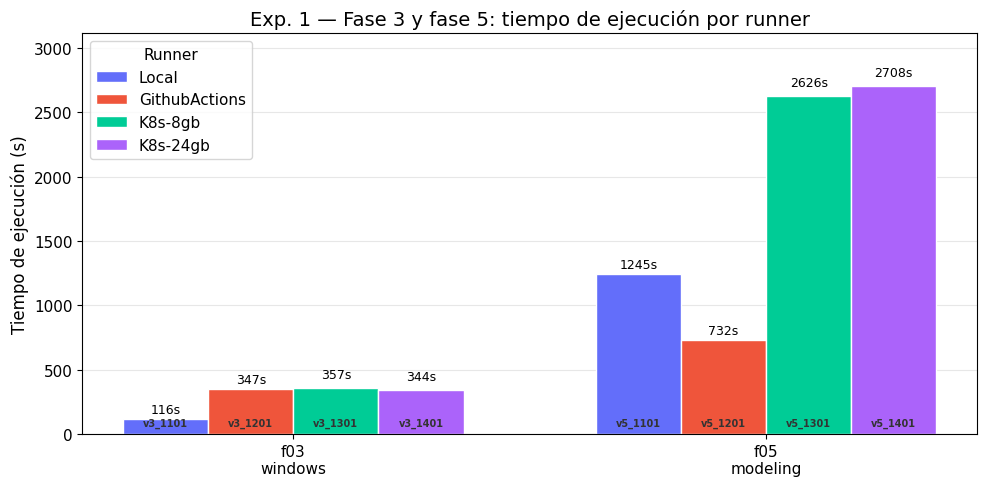

In [116]:
# ── Experimento 1: Eficiencia de Recursos ──
df1 = df[(df["experiment"] == 1) & (df["variant"].isin(selected_variants))].copy()

phase_order = ["f03_windows", "f05_modeling"]
phases = [phase for phase in phase_order if phase in df1["phase"].unique()]
runners = [r for r in RUNNER_ORDER if r in df1["runner"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))

n_phases = len(phases)
n_runners = len(runners)
bar_width = 0.18
x = np.arange(n_phases)

max_time = 0

for i, runner in enumerate(runners):
    times = []
    variants = []

    for phase in phases:
        mask = (df1["phase"] == phase) & (df1["runner"] == runner)
        row = df1.loc[mask, ["execution_seconds", "variant"]]

        if len(row) > 0:
            t = row.iloc[0]["execution_seconds"]
            times.append(t)
            variants.append(str(row.iloc[0]["variant"]))
            max_time = max(max_time, t)
        else:
            times.append(0)
            variants.append("")

    offset = (i - n_runners / 2 + 0.5) * bar_width

    bars = ax.bar(
        x + offset,
        times,
        bar_width,
        label=runner,
        color=RUNNER_COLORS[runner],
        edgecolor="white",
        zorder=2
    )

    for bar, t, v in zip(bars, times, variants):
        if t > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + max_time * 0.02,
                f"{t:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                zorder=5
            )

            ax.text(
                bar.get_x() + bar.get_width()/2,
                0.015,
                f"{v}",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color="#333",
                rotation=0,
                transform=ax.get_xaxis_transform(),
                zorder=5,
                clip_on=False
            )

ax.set_xticks(x)
ax.set_xticklabels([p.replace("_", "\n") for p in phases])

ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Fase 3 y fase 5: tiempo de ejecución por runner")
ax.legend(title="Runner")

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(bottom=0, top=max_time * 1.15)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/comparativa_tiempos_runner.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis

> **Espacio para conclusiones.** Comparar los tiempos entre runners. ¿Compensa K8s-24gb frente a K8s-8gb considerando que permite 3 pods vs 5? Calcular el *throughput efectivo* (variantes/hora) para cada runner.


---
## 1.1 Diferentes runners sobre github actions

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


In [117]:
# ── Selección de variantes (Exp. 1.1 — GHA) ──
_exp = df[(df["experiment"] == 1) & (df["runner"] == "GithubActions")]
print("Variantes disponibles (Exp. 1, GithubActions):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "variant"]).to_string(index=False))

selected_variants = [
    "v5_1201",
    "v5_1202",
    "v5_1203",
    "v5_1204",
    "v5_1205",
    "v5_1206",
]
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 1, GithubActions):
variant        phase        runner  status
v3_1201  f03_windows GithubActions success
v5_1201 f05_modeling GithubActions success
v5_1202 f05_modeling GithubActions success
v5_1203 f05_modeling GithubActions success
v5_1204 f05_modeling GithubActions success
v5_1205 f05_modeling GithubActions success
v5_1206 f05_modeling GithubActions success

Seleccionadas (6): ['v5_1201', 'v5_1202', 'v5_1203', 'v5_1204', 'v5_1205', 'v5_1206']


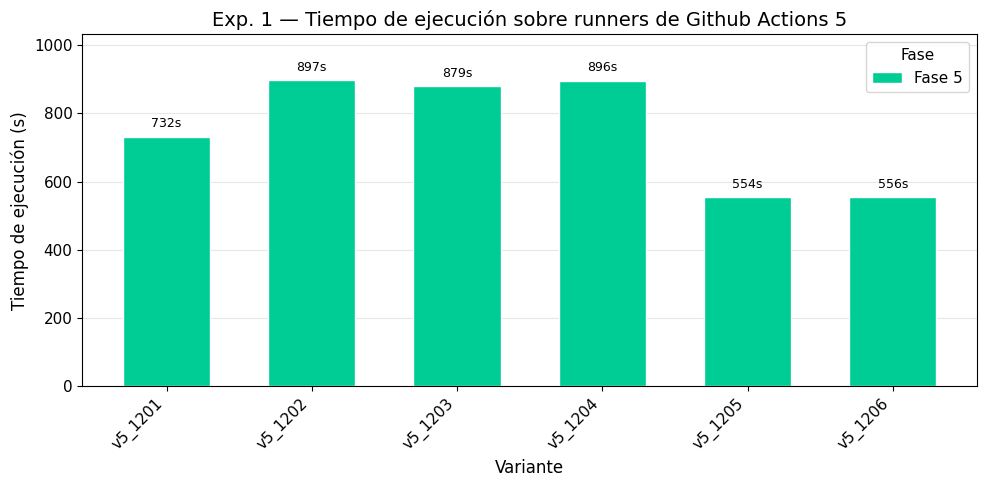

In [118]:
# ── Experimento 1.1: GithubActions ──
phase_order = ["f03_windows", "f05_modeling"]
phase_labels = {
    "f03_windows": "Fase 3",
    "f05_modeling": "Fase 5",
}
phase_colors = {
    "f03_windows": "#636EFA",
    "f05_modeling": "#00CC96",
}

df1 = df[(df["experiment"] == 1) & (df["variant"].isin(selected_variants)) & (df["phase"].isin(phase_order))].copy()
phases = [phase for phase in phase_order if phase in df1["phase"].unique()]
variants = [variant for variant in selected_variants if variant in df1["variant"].unique()]

pivot = df1.pivot_table(
    index="variant",
    columns="phase",
    values="execution_seconds",
    aggfunc="first"
).reindex(index=variants, columns=phases)

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 1.1), 5))

n_phases = len(phases)
bar_width = 0.35 if n_phases > 1 else 0.6
x = np.arange(len(variants))

max_time = float(np.nanmax(pivot.to_numpy())) if not pivot.empty else 0
if np.isnan(max_time):
    max_time = 0

for i, phase in enumerate(phases):
    times = pivot[phase].fillna(0).to_numpy()
    offset = (i - (n_phases - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        times,
        bar_width,
        label=phase_labels.get(phase, phase),
        color=phase_colors.get(phase, "#999"),
        edgecolor="white",
        zorder=2
    )

    for bar, t in zip(bars, times):
        if t > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_time * 0.02,
                f"{t:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                zorder=5
            )

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=45, ha="right")

ax.set_xlabel("Variante")
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Tiempo de ejecución sobre runners de Github Actions 5")
ax.legend(title="Fase")

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(bottom=0, top=max_time * 1.15 if max_time > 0 else 1)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/exp11_github_actions_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 1.2 Diferentes runners sobre runners de cluster k8s-8gb

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


In [119]:
# ── Selección de variantes (Exp. 1.2 — K8s-8gb, f03) ──
_exp = df[(df["experiment"] == 1) & (df["runner"] == "K8s-8gb")]
print("Variantes disponibles (Exp. 1, K8s-8gb):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "variant"]).to_string(index=False))

selected_variants = [
    "v3_1301",
    "v3_1302",
    "v3_1303",
    "v3_1304",
    "v3_1305",
    "v3_1306",
]
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 1, K8s-8gb):
variant        phase  runner  status
v3_1301  f03_windows K8s-8gb success
v3_1302  f03_windows K8s-8gb success
v3_1303  f03_windows K8s-8gb success
v3_1304  f03_windows K8s-8gb success
v3_1305  f03_windows K8s-8gb success
v3_1306  f03_windows K8s-8gb success
v5_1301 f05_modeling K8s-8gb success
v5_1302 f05_modeling K8s-8gb success
v5_1303 f05_modeling K8s-8gb success
v5_1304 f05_modeling K8s-8gb success
v5_1305 f05_modeling K8s-8gb success
v5_1306 f05_modeling K8s-8gb success

Seleccionadas (6): ['v3_1301', 'v3_1302', 'v3_1303', 'v3_1304', 'v3_1305', 'v3_1306']


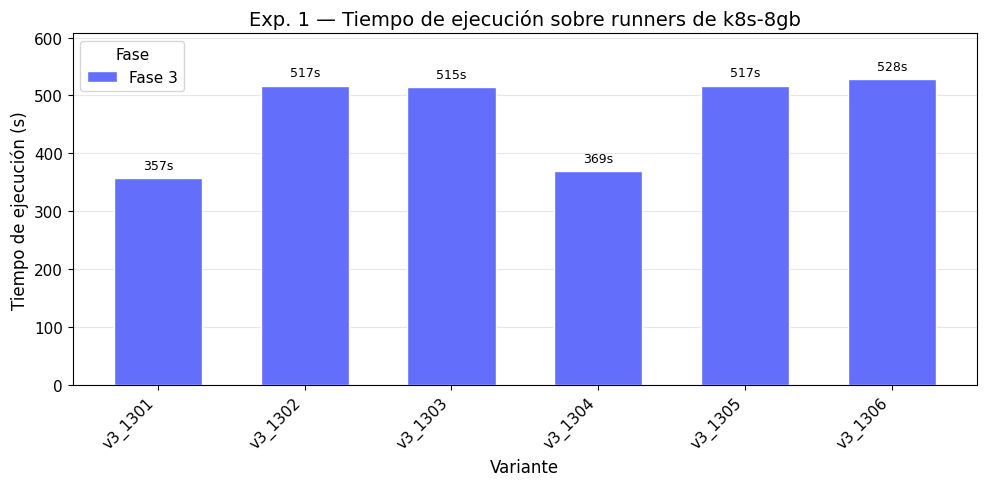

In [120]:
# ── Experimento 1.2: K8s-8gb (f03) ──
phase_order = ["f03_windows", "f05_modeling"]
phase_labels = {
    "f03_windows": "Fase 3",
    "f05_modeling": "Fase 5",
}
phase_colors = {
    "f03_windows": "#636EFA",
    "f05_modeling": "#00CC96",
}

df1 = df[(df["experiment"] == 1) & (df["variant"].isin(selected_variants)) & (df["phase"].isin(phase_order))].copy()
phases = [phase for phase in phase_order if phase in df1["phase"].unique()]
variants = [variant for variant in selected_variants if variant in df1["variant"].unique()]

pivot = df1.pivot_table(
    index="variant",
    columns="phase",
    values="execution_seconds",
    aggfunc="first"
).reindex(index=variants, columns=phases)

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 1.1), 5))

n_phases = len(phases)
bar_width = 0.35 if n_phases > 1 else 0.6
x = np.arange(len(variants))

max_time = float(np.nanmax(pivot.to_numpy())) if not pivot.empty else 0
if np.isnan(max_time):
    max_time = 0

for i, phase in enumerate(phases):
    times = pivot[phase].fillna(0).to_numpy()
    offset = (i - (n_phases - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        times,
        bar_width,
        label=phase_labels.get(phase, phase),
        color=phase_colors.get(phase, "#999"),
        edgecolor="white",
        zorder=2
    )

    for bar, t in zip(bars, times):
        if t > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_time * 0.02,
                f"{t:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                zorder=5
            )

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=45, ha="right")

ax.set_xlabel("Variante")
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Tiempo de ejecución sobre runners de k8s-8gb")
ax.legend(title="Fase")

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(bottom=0, top=max_time * 1.15 if max_time > 0 else 1)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/exp12_k8s_8gb_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 1.3 Diferentes runners sobre runners de cluster k8s-8b

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


In [121]:
# ── Selección de variantes (Exp. 1.3 — K8s-8gb, f05) ──
_exp = df[(df["experiment"] == 1) & (df["runner"] == "K8s-8gb")]
print("Variantes disponibles (Exp. 1, K8s-8gb):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "variant"]).to_string(index=False))

selected_variants = [
    "v5_1301",
    "v5_1302",
    "v5_1303",
    "v5_1304",
    "v5_1305",
    "v5_1306",
]
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 1, K8s-8gb):
variant        phase  runner  status
v3_1301  f03_windows K8s-8gb success
v3_1302  f03_windows K8s-8gb success
v3_1303  f03_windows K8s-8gb success
v3_1304  f03_windows K8s-8gb success
v3_1305  f03_windows K8s-8gb success
v3_1306  f03_windows K8s-8gb success
v5_1301 f05_modeling K8s-8gb success
v5_1302 f05_modeling K8s-8gb success
v5_1303 f05_modeling K8s-8gb success
v5_1304 f05_modeling K8s-8gb success
v5_1305 f05_modeling K8s-8gb success
v5_1306 f05_modeling K8s-8gb success

Seleccionadas (6): ['v5_1301', 'v5_1302', 'v5_1303', 'v5_1304', 'v5_1305', 'v5_1306']


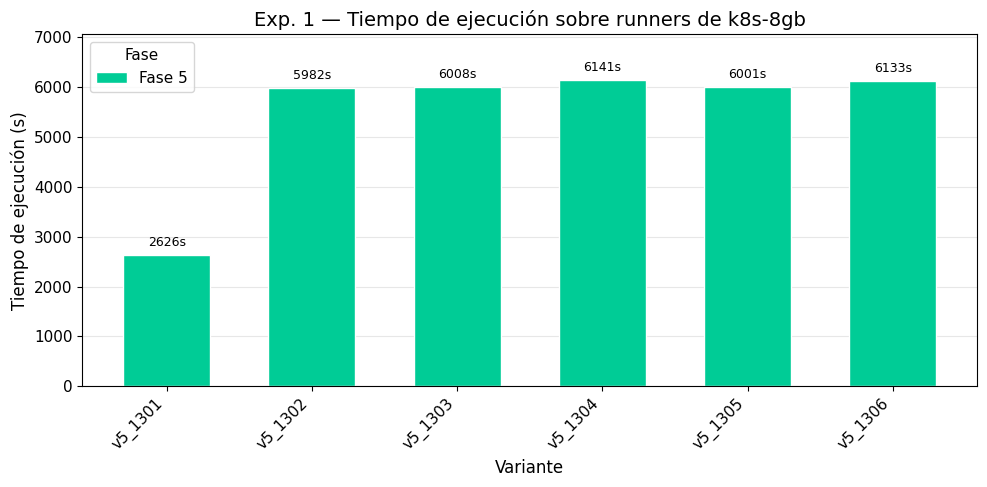

In [122]:
# ── Experimento 1.3: K8s-8gb (f05) ──
phase_order = ["f03_windows", "f05_modeling"]
phase_labels = {
    "f03_windows": "Fase 3",
    "f05_modeling": "Fase 5",
}
phase_colors = {
    "f03_windows": "#636EFA",
    "f05_modeling": "#00CC96",
}

df1 = df[(df["experiment"] == 1) & (df["variant"].isin(selected_variants)) & (df["phase"].isin(phase_order))].copy()
phases = [phase for phase in phase_order if phase in df1["phase"].unique()]
variants = [variant for variant in selected_variants if variant in df1["variant"].unique()]

pivot = df1.pivot_table(
    index="variant",
    columns="phase",
    values="execution_seconds",
    aggfunc="first"
).reindex(index=variants, columns=phases)

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 1.1), 5))

n_phases = len(phases)
bar_width = 0.35 if n_phases > 1 else 0.6
x = np.arange(len(variants))

max_time = float(np.nanmax(pivot.to_numpy())) if not pivot.empty else 0
if np.isnan(max_time):
    max_time = 0

for i, phase in enumerate(phases):
    times = pivot[phase].fillna(0).to_numpy()
    offset = (i - (n_phases - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        times,
        bar_width,
        label=phase_labels.get(phase, phase),
        color=phase_colors.get(phase, "#999"),
        edgecolor="white",
        zorder=2
    )

    for bar, t in zip(bars, times):
        if t > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_time * 0.02,
                f"{t:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                zorder=5
            )

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=45, ha="right")

ax.set_xlabel("Variante")
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Tiempo de ejecución sobre runners de k8s-8gb")
ax.legend(title="Fase")

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(bottom=0, top=max_time * 1.15 if max_time > 0 else 1)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/exp13_k8s_8gb_repetibilidad.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 1.4 Diferentes runners sobre runners de cluster k8s-24b

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


In [123]:
# ── Selección de variantes (Exp. 1.4 — K8s-24gb) ──
_exp = df[(df["experiment"] == 1) & (df["runner"] == "K8s-24gb")]
print("Variantes disponibles (Exp. 1, K8s-24gb):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "variant"]).to_string(index=False))

selected_variants = [
    "v5_1401",
    "v5_1402",
    "v5_1403",
    "v5_1404",
    "v5_1405",
    "v5_1406",
]
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 1, K8s-24gb):
variant        phase   runner  status
v3_1401  f03_windows K8s-24gb success
v5_1401 f05_modeling K8s-24gb success
v5_1402 f05_modeling K8s-24gb  failed
v5_1403 f05_modeling K8s-24gb  failed
v5_1404 f05_modeling K8s-24gb  failed
v5_1405 f05_modeling K8s-24gb success
v5_1406 f05_modeling K8s-24gb success

Seleccionadas (6): ['v5_1401', 'v5_1402', 'v5_1403', 'v5_1404', 'v5_1405', 'v5_1406']


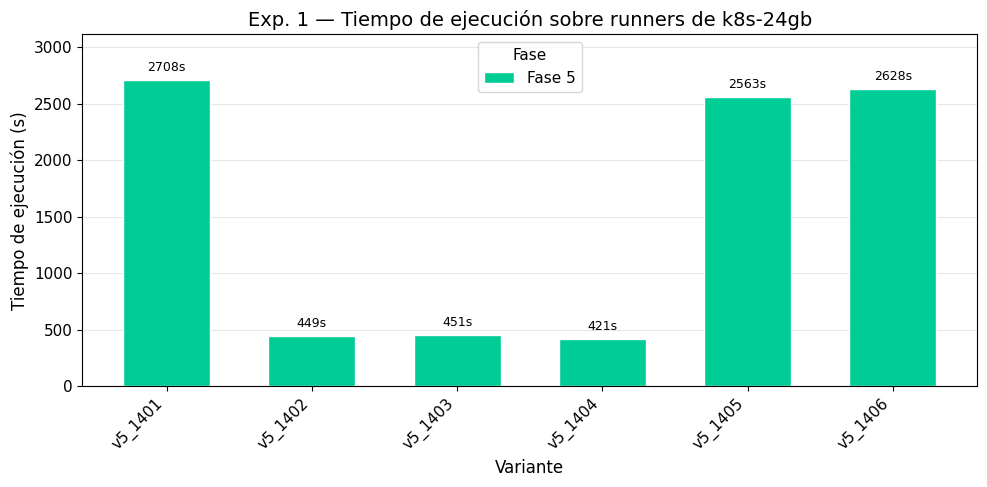

In [124]:
# ── Experimento 1.4: K8s-24gb ──
phase_order = ["f03_windows", "f05_modeling"]
phase_labels = {
    "f03_windows": "Fase 3",
    "f05_modeling": "Fase 5",
}
phase_colors = {
    "f03_windows": "#636EFA",
    "f05_modeling": "#00CC96",
}

df1 = df[(df["experiment"] == 1) & (df["variant"].isin(selected_variants)) & (df["phase"].isin(phase_order))].copy()
phases = [phase for phase in phase_order if phase in df1["phase"].unique()]
variants = [variant for variant in selected_variants if variant in df1["variant"].unique()]

pivot = df1.pivot_table(
    index="variant",
    columns="phase",
    values="execution_seconds",
    aggfunc="first"
).reindex(index=variants, columns=phases)

fig, ax = plt.subplots(figsize=(max(10, len(variants) * 1.1), 5))

n_phases = len(phases)
bar_width = 0.35 if n_phases > 1 else 0.6
x = np.arange(len(variants))

max_time = float(np.nanmax(pivot.to_numpy())) if not pivot.empty else 0
if np.isnan(max_time):
    max_time = 0

for i, phase in enumerate(phases):
    times = pivot[phase].fillna(0).to_numpy()
    offset = (i - (n_phases - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        times,
        bar_width,
        label=phase_labels.get(phase, phase),
        color=phase_colors.get(phase, "#999"),
        edgecolor="white",
        zorder=2
    )

    for bar, t in zip(bars, times):
        if t > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_time * 0.02,
                f"{t:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                zorder=5
            )

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=45, ha="right")

ax.set_xlabel("Variante")
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Tiempo de ejecución sobre runners de k8s-24gb")
ax.legend(title="Fase")

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(bottom=0, top=max_time * 1.15 if max_time > 0 else 1)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/exp14_k8s_24gb_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Saturación y Colas de Espera — Estrés del Sistema

**Objetivo:** Verificar que el sistema gestiona correctamente ráfagas de ejecuciones que superan `max-parallel`.

**Diseño:** 8 variantes de `f03_windows` lanzadas simultáneamente en `K8s-8gb` (max-parallel=5). Las 5 primeras deben arrancar inmediatamente; las 3 restantes deben quedar en cola.

**Gráfica:** Timeline horizontal diferenciando tiempo en cola vs. ejecución activa.


In [125]:
# ── Selección de variantes (Exp. 2) ──
_exp = df[df["experiment"] == 2]
print("Variantes disponibles (Exp. 2):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "runner", "variant"]).to_string(index=False))


selected_variants = [
    "v3_2301",
    "v3_2302",
    "v3_2303",
    "v3_2305",
    "v3_2306",
    "v3_2307",
    "v3_2308"
]


# selected_variants = sorted(_exp["variant"].unique().tolist())
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 2):
variant       phase        runner  status
v3_2304 f03_windows GithubActions success
v3_2301 f03_windows       K8s-8gb success
v3_2302 f03_windows       K8s-8gb success
v3_2303 f03_windows       K8s-8gb success
v3_2305 f03_windows       K8s-8gb success
v3_2306 f03_windows       K8s-8gb success
v3_2307 f03_windows       K8s-8gb success
v3_2308 f03_windows       K8s-8gb success

Seleccionadas (7): ['v3_2301', 'v3_2302', 'v3_2303', 'v3_2305', 'v3_2306', 'v3_2307', 'v3_2308']


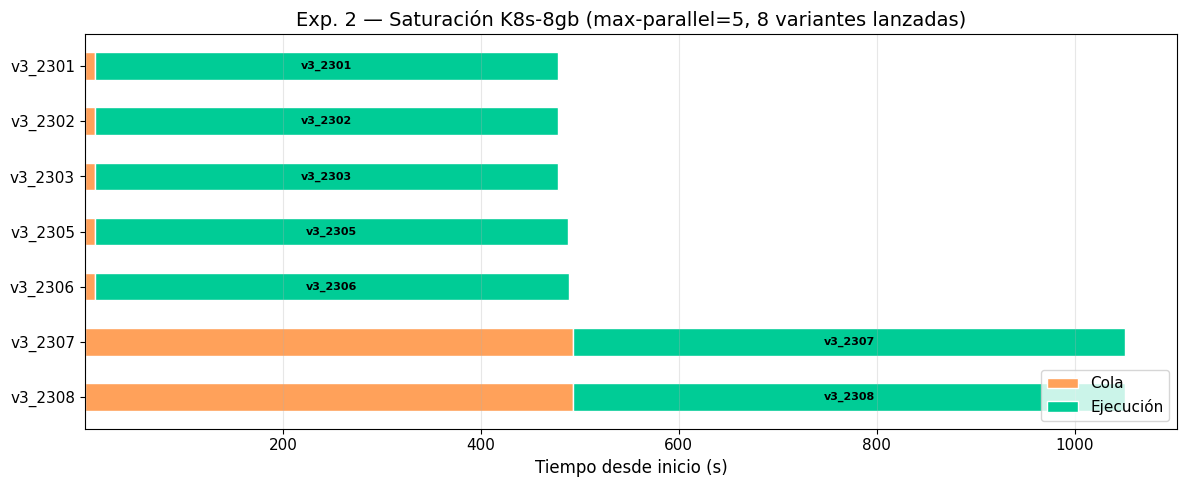


Resumen de tiempos:
variant  queue_seconds  execution_seconds  total_seconds
v3_2301           10.0              467.0            477
v3_2302           10.0              467.0            477
v3_2303           10.0              467.0            477
v3_2305           10.0              478.0            488
v3_2306           10.0              478.0            488
v3_2307          493.0              557.0           1050
v3_2308          493.0              557.0           1050


In [126]:
# ── Experimento 2: Saturación y Colas ──
df2 = df[(df["experiment"] == 2) & (df["variant"].isin(selected_variants))].copy().sort_values("created_at")

t0 = df2["created_at"].min()
df2["queue_start"] = (df2["created_at"] - t0).dt.total_seconds()
df2["exec_start"]  = (df2["started_at"] - t0).dt.total_seconds()
df2["exec_end"]    = (df2["completed_at"] - t0).dt.total_seconds()

fig, ax = plt.subplots(figsize=(12, 5))

y_labels = df2["variant"].tolist()
y_pos = range(len(y_labels))

for i, (_, row) in enumerate(df2.iterrows()):
    queue_duration = row["exec_start"] - row["queue_start"]
    if queue_duration > 0:
        ax.barh(i, queue_duration, left=row["queue_start"],
                height=0.5, color="#FFA15A", edgecolor="white", label="Cola" if i == 0 else "")
    exec_duration = row["exec_end"] - row["exec_start"]
    ax.barh(i, exec_duration, left=row["exec_start"],
            height=0.5, color="#00CC96", edgecolor="white", label="Ejecución" if i == 0 else "")

    ax.text(row["exec_start"] + exec_duration / 2, i, str(row["variant"]),
            ha="center", va="center", fontsize=8, color="black", fontweight="bold")

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Tiempo desde inicio (s)")
ax.set_title("Exp. 2 — Saturación K8s-8gb (max-parallel=5, 8 variantes lanzadas)")
ax.invert_yaxis()

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/robustez_logs_error.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumen de tiempos:")
print(df2[["variant", "queue_seconds", "execution_seconds", "total_seconds"]].to_string(index=False))

### Análisis

> **Espacio para conclusiones.** Verificar que las variantes 6-8 muestran un tiempo en cola ≈ al tiempo de ejecución de las primeras 5. Confirmar que no hay fallos ni corrupción de datos. Calcular la utilización media del clúster.


---
## 3. Validación Virtual vs. Real — Fases 7 y 8

**Objetivo:** Comparar la ejecución de las fase7 y 8 en:
1. Local esp32 Real
2. Local esp32 Simulada
3. VM esp32 Real
4. VM esp32 vistualizar


**Diseño:** Ejecutar `f07_modval` y `f08_sysval` en en todos los entornos con un mismo dataset (5000 filas).

**Nota:** En f07, el tiempo de compilación es lo que diferencia los entornos; el tiempo de inferencia está regulado por `MTI_MS`. La comparación debe separar ambos componentes.

**Gráfica:** Barras agrupadas comparando las diferentes ejecuciones.


In [127]:
# ── Selección de variantes (Exp. 3) ──
_exp = df[df["experiment"] == 3]
print("Variantes disponibles (Exp. 3):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "runner", "variant"]).to_string(index=False))



selected_variants = [
    "v7_3101",
    "v7_3301",
    "v7_3501",
    "v8_3101",
    "v8_3301",
    "v8_3501",
]

# selected_variants = sorted(_exp["variant"].unique().tolist())
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 3):
variant      phase           runner  status
v7_3301 f07_modval         ESP32-v1 success
v7_3303 f07_modval         ESP32-v1 success
v7_3401 f07_modval         ESP32-v2 success
v7_3501 f07_modval ESP32-v3-virtual success
v7_3503 f07_modval ESP32-v3-virtual  failed
v7_3601 f07_modval ESP32-v4-virtual success
v7_3101 f07_modval            Local success
v7_3102 f07_modval            Local success
v8_3102 f08_sysval         ESP32-v1 success
v8_3301 f08_sysval         ESP32-v1 success
v8_3501 f08_sysval ESP32-v3-virtual success
v8_3101 f08_sysval            Local success
v8_3103 f08_sysval            Local  failed

Seleccionadas (6): ['v7_3101', 'v7_3301', 'v7_3501', 'v8_3101', 'v8_3301', 'v8_3501']


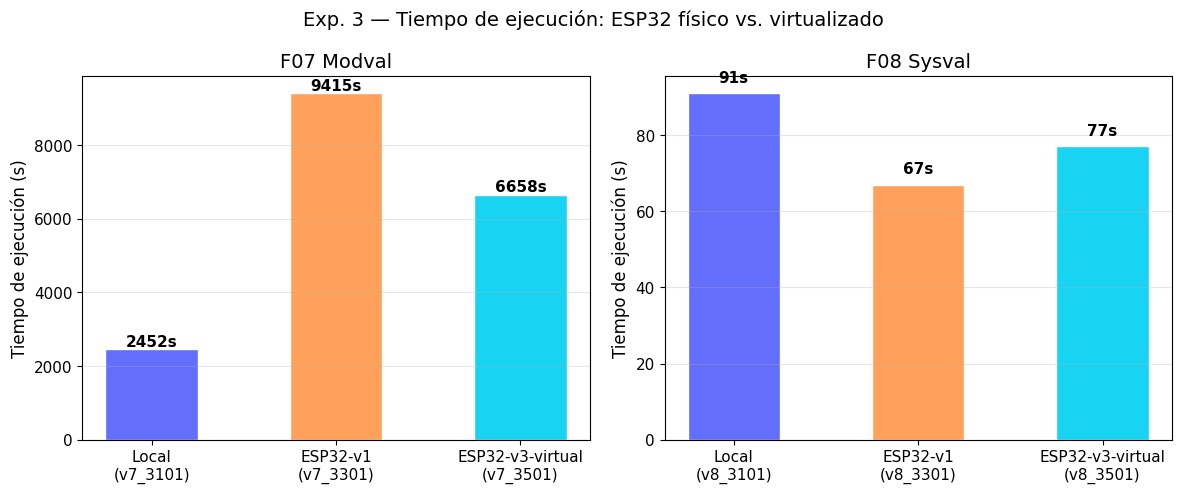


Resumen:
variant      phase           runner  execution_seconds  status
v7_3501 f07_modval ESP32-v3-virtual             6658.0 success
v7_3301 f07_modval         ESP32-v1             9415.0 success
v8_3301 f08_sysval         ESP32-v1               67.0 success
v8_3501 f08_sysval ESP32-v3-virtual               77.0 success
v7_3101 f07_modval            Local             2452.0 success
v8_3101 f08_sysval            Local               91.0 success


In [128]:
# ── Experimento 3: Virtual vs. Real ──
df3 = df[(df["experiment"] == 3) & (df["variant"].isin(selected_variants))].copy()

phases = ["f07_modval", "f08_sysval"]
runners_3 = [r for r in RUNNER_ORDER if r in df3["runner"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for idx, phase in enumerate(phases):
    ax = axes[idx]
    subset = df3[df3["phase"] == phase]

    bars_data = []
    variants_data = []
    for runner in runners_3:
        row = subset[subset["runner"] == runner]
        if len(row) > 0:
            bars_data.append(row.iloc[0]["execution_seconds"])
            variants_data.append(str(row.iloc[0]["variant"]))
        else:
            bars_data.append(0)
            variants_data.append("")

    colors = [RUNNER_COLORS.get(r, "#999") for r in runners_3]
    x_pos = np.arange(len(runners_3))
    bars = ax.bar(x_pos, bars_data, color=colors, edgecolor="white", width=0.5)

    for bar, val in zip(bars, bars_data):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f"{val:.0f}s", ha="center", va="bottom", fontsize=11, fontweight="bold")

    xtick_labels = []
    for runner, var_id in zip(runners_3, variants_data):
        if var_id:
            xtick_labels.append(f"{runner}\n({var_id})")
        else:
            xtick_labels.append(runner)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(xtick_labels)

    ax.set_title(phase.replace("_", " ").title())
    ax.set_ylabel("Tiempo de ejecución (s)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Exp. 3 — Tiempo de ejecución: ESP32 físico vs. virtualizado", fontsize=14)
plt.tight_layout()
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/arquitectura_hitl_esp32.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumen:")
print(df3[["variant", "phase", "runner", "execution_seconds", "status"]].to_string(index=False))

### Análisis

> **Espacio para conclusiones.** ¿Los resultados de inferencia son idénticos? ¿El ratio de tiempo es constante o varía por fase? Si la fidelidad es alta, esto valida las pre-validaciones masivas en entornos virtualizados.


---
## 4. Valor de la Paralelización — Gantt de Ejecución

**Objetivo:** Cuantificar la reducción de Lead Time ejecutando variantes en paralelo frente a secuencial.

**Diseño del lote:**
```
f01 (1 variante)
 ├── f02-A ──┬── f03-A1 ── f04-A1a
 │           └── f03-A2 ── f04-A2a
 │                        └── f04-A2b
 └── f02-B ──┬── f03-B1 ── f04-B1a
              └── f03-B2 ── f04-B2a
                           └── f04-B2b
```

**Gráfica:** Diagrama de Gantt con dos paneles (secuencial vs. paralelo) + línea de camino crítico.


In [129]:
# ── Selección de variantes (Exp. 4) ──
_exp = df[df["experiment"] == 4]
print("Variantes disponibles (Exp. 4):")
print(_exp[["variant", "phase", "runner", "status"]].sort_values(["phase", "runner", "variant"]).to_string(index=False))

selected_variants = sorted(_exp["variant"].unique().tolist())
print(f"\nSeleccionadas ({len(selected_variants)}):", selected_variants)

Variantes disponibles (Exp. 4):
variant       phase        runner   status
v1_4301 f01_explore GithubActions  success
v1_4101 f01_explore         Local  success
v2_4301  f02_events GithubActions  success
v2_4302  f02_events GithubActions  success
v2_4101  f02_events         Local  success
v2_4102  f02_events         Local  success
v3_4301 f03_windows GithubActions  success
v3_4302 f03_windows GithubActions  success
v3_4303 f03_windows GithubActions  success
v3_4304 f03_windows GithubActions  success
v3_4101 f03_windows         Local  success
v3_4102 f03_windows         Local  success
v3_4103 f03_windows         Local  success
v3_4104 f03_windows         Local  success
v4_4301 f04_targets GithubActions  success
v4_4302 f04_targets GithubActions  success
v4_4303 f04_targets GithubActions  success
v4_4304 f04_targets GithubActions   failed
v4_4305 f04_targets GithubActions   failed
v4_4306 f04_targets GithubActions   failed
v4_4101 f04_targets         Local  success
v4_4102 f04_targets   

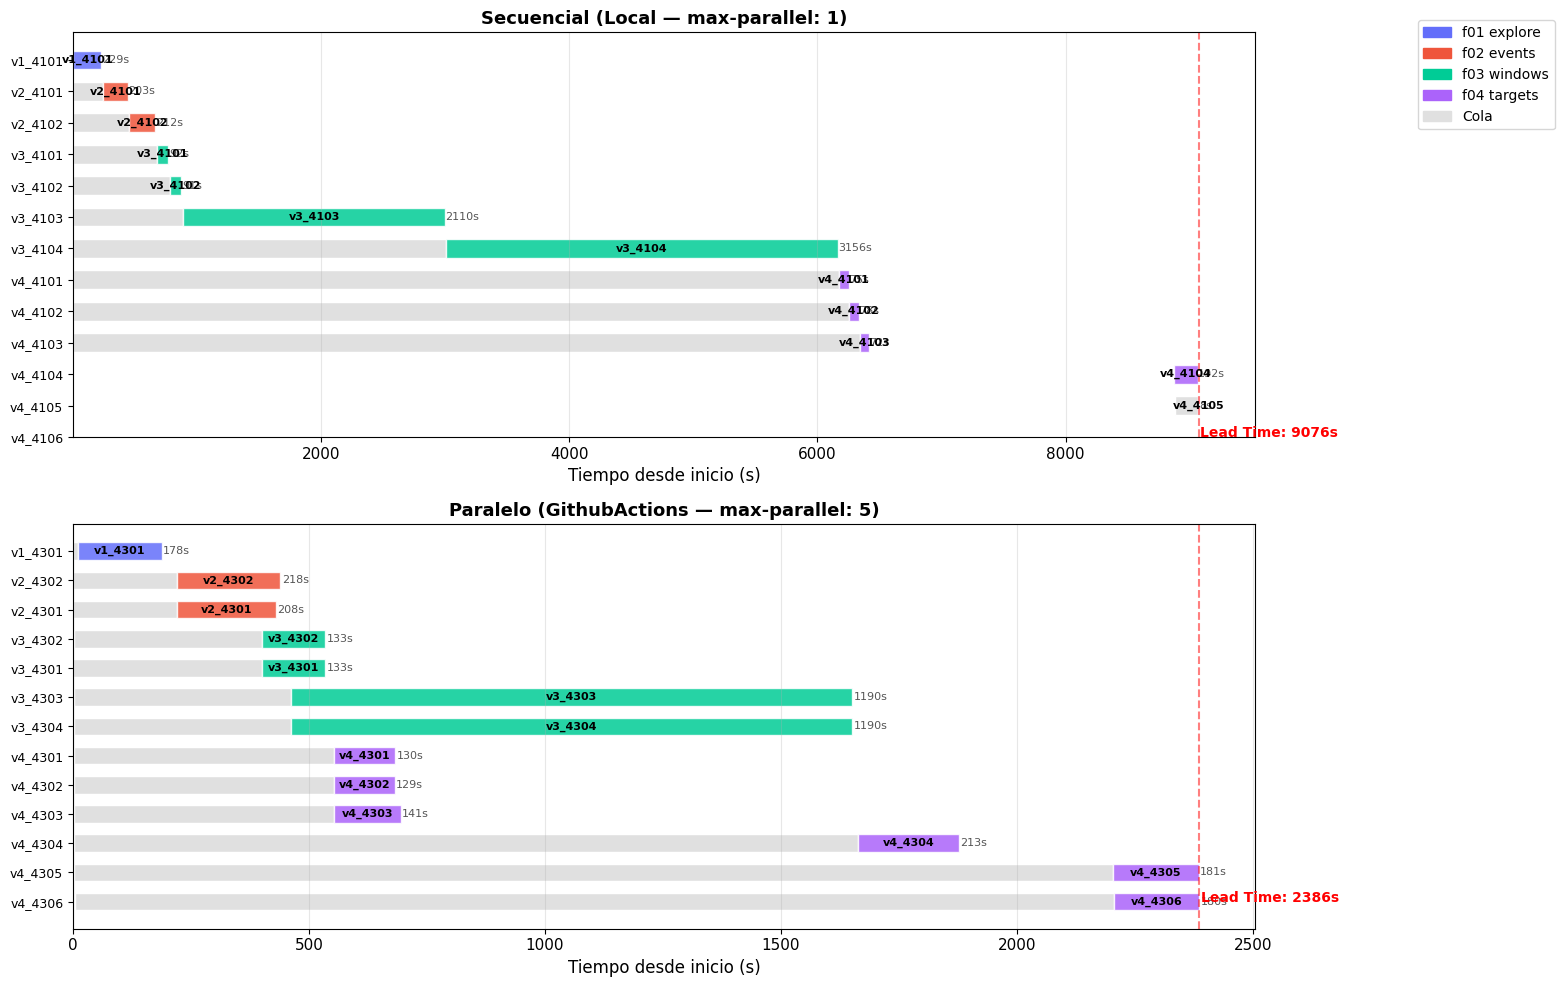


Lead Time Secuencial:  9076s (151.3 min)
Lead Time Paralelo:    2386s (39.8 min)
Speedup:               3.80x
Reducción:             73.7%


In [130]:
# ── Experimento 4: Gantt de Paralelización ──
df4 = df[(df["experiment"] == 4) & (df["variant"].isin(selected_variants))].copy()

df4_seq = df4[df4["runner"] == "Local"].copy().sort_values("started_at")
df4_par = df4[df4["runner"] == "GithubActions"].copy().sort_values("started_at")

PHASE_COLORS = {
    "f01_explore": "#636EFA",
    "f02_events":  "#EF553B",
    "f03_windows": "#00CC96",
    "f04_targets": "#AB63FA",
}

def plot_gantt(ax, data, title, show_critical=False):
    t0 = data["created_at"].min()

    y_labels = data["variant"].tolist()

    for i, (_, row) in enumerate(data.iterrows()):
        start = (row["started_at"] - t0).total_seconds()
        duration = row["execution_seconds"]
        queue = (row["started_at"] - row["created_at"]).total_seconds()

        if queue > 1:
            q_start = (row["created_at"] - t0).total_seconds()
            ax.barh(i, queue, left=q_start, height=0.6,
                    color="#E0E0E0", edgecolor="white")

        color = PHASE_COLORS.get(row["phase"], "#999")
        ax.barh(i, duration, left=start, height=0.6,
                color=color, edgecolor="white", alpha=0.85)

        ax.text(start + duration + 3, i, f"{duration:.0f}s",
                va="center", fontsize=8, color="#555")

        ax.text(start + duration / 2, i, str(row["variant"]),
                ha="center", va="center", fontsize=8, color="black", fontweight="bold")

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel("Tiempo desde inicio (s)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

    total = (data["completed_at"].max() - t0).total_seconds()
    ax.axvline(x=total, color="red", linestyle="--", alpha=0.5)
    ax.text(total + 5, len(y_labels) - 1, f"Lead Time: {total:.0f}s",
            color="red", fontsize=10, fontweight="bold")

    return total


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

lt_seq = plot_gantt(ax1, df4_seq, "Secuencial (Local — max-parallel: 1)")
lt_par = plot_gantt(ax2, df4_par, "Paralelo (GithubActions — max-parallel: 5)")

legend_patches = [mpatches.Patch(color=c, label=p.replace("_", " "))
                  for p, c in PHASE_COLORS.items()]
legend_patches.append(mpatches.Patch(color="#E0E0E0", label="Cola"))
fig.legend(handles=legend_patches, loc="upper right", fontsize=10,
           bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.85, 1])
if EXPORT_FIGURES:
    os.makedirs("figures/validacion", exist_ok=True)
    fig.savefig("figures/validacion/paralelizacion_variantes.png", dpi=150, bbox_inches="tight")
plt.show()

speedup = lt_seq / lt_par if lt_par > 0 else float("inf")
print(f"\n{'='*50}")
print(f"Lead Time Secuencial:  {lt_seq:.0f}s ({lt_seq/60:.1f} min)")
print(f"Lead Time Paralelo:    {lt_par:.0f}s ({lt_par/60:.1f} min)")
print(f"Speedup:               {speedup:.2f}x")
print(f"Reducción:             {(1 - lt_par/lt_seq)*100:.1f}%")

In [131]:
# ── Camino Crítico (mínimo teórico) ──
# El camino crítico es la rama más larga de dependencias.
# Para calcularlo, recorremos el DAG de parent → child y sumamos tiempos.

def compute_critical_path(data):
    """Compute the critical path through the variant dependency DAG."""
    exec_map = dict(zip(data["variant"], data["execution_seconds"]))
    parent_map = dict(zip(data["variant"], data["parent_variant"]))
    queue_map = dict(zip(data["variant"], data["queue_seconds"]))

    def longest_path(variant):
        t = exec_map.get(variant, 0)
        parent = parent_map.get(variant, "")
        if parent and parent in exec_map:
            t += longest_path(parent)
        return t

    paths = {v: longest_path(v) for v in data["variant"]}
    critical_variant = max(paths, key=paths.get)
    critical_time = paths[critical_variant]

    # Reconstruct path
    path = []
    v = critical_variant
    while v and v in exec_map:
        path.append(v)
        v = parent_map.get(v, "")
    path.reverse()

    return critical_time, path

cp_time, cp_path = compute_critical_path(df4_par)

print(f"Camino Crítico (mínimo teórico): {cp_time:.0f}s ({cp_time/60:.1f} min)")
print(f"Ruta: {' → '.join(cp_path)}")
print(f"\nEficiencia del sistema paralelo: {cp_time/lt_par*100:.1f}% del óptimo teórico")
print(f"Eficiencia del sistema secuencial: {cp_time/lt_seq*100:.1f}% del óptimo teórico")


Camino Crítico (mínimo teórico): 1799s (30.0 min)
Ruta: v1_4301 → v2_4302 → v3_4303 → v4_4304

Eficiencia del sistema paralelo: 75.4% del óptimo teórico
Eficiencia del sistema secuencial: 19.8% del óptimo teórico


### Análisis

> **Espacio para conclusiones.** Cuantificar el speedup y la eficiencia respecto al camino crítico. La frase clave: *"El sistema alcanza un Lead Time de X segundos, a un Y% del límite teórico impuesto por las dependencias del pipeline, frente al Z% que supone la ejecución secuencial."*


---
## Resumen y Cierre

> **TODO:** Tabla resumen / matriz de decisión consolidando los resultados de los 4 experimentos.
> Columnas: Runner × Velocidad relativa × Paralelismo × Coste/disponibilidad × Tipo de fase recomendado.


In [132]:
# ── Tabla resumen ──
summary = pd.DataFrame({
    "Runner": RUNNER_ORDER,
    "max-parallel": [1, 20, 5, 3, 1, 1, 1, 1],
    "Mejor para": [
        "Baseline / debug",
        "Fases ligeras masivas (f01-f04)",
        "Balance paralelismo/recursos (f05)",
        "Fases con alta demanda de RAM",
        "Validación HW real (f07/f08)",
        "Validación HW real (f07/f08)",
        "Pre-validación virtual (f07/f08)",
        "Pre-validación virtual (f07/f08)",
    ],
    "Limitaciones": [
        "Sin paralelismo",
        "Timeout 6h, recursos genéricos, cuota mensual",
        "Recursos compartidos del clúster",
        "Solo 3 pods concurrentes",
        "1 dispositivo físico",
        "1 dispositivo físico",
        "Fidelidad depende de emulación",
        "Fidelidad depende de emulación",
    ]
})
print(summary.to_string(index=False))

          Runner  max-parallel                         Mejor para                                  Limitaciones
           Local             1                   Baseline / debug                               Sin paralelismo
   GithubActions            20    Fases ligeras masivas (f01-f04) Timeout 6h, recursos genéricos, cuota mensual
         K8s-8gb             5 Balance paralelismo/recursos (f05)              Recursos compartidos del clúster
        K8s-24gb             3      Fases con alta demanda de RAM                      Solo 3 pods concurrentes
        ESP32-v1             1       Validación HW real (f07/f08)                          1 dispositivo físico
        ESP32-v2             1       Validación HW real (f07/f08)                          1 dispositivo físico
ESP32-v3-virtual             1   Pre-validación virtual (f07/f08)                Fidelidad depende de emulación
ESP32-v4-virtual             1   Pre-validación virtual (f07/f08)                Fidelidad depende de em

---
## Exportar figuras

In [ ]:
# ── Verificar figuras exportadas ──
EXPECTED_FIGURES = [
    "figures/validacion/comparativa_tiempos_runner.png",
    "figures/validacion/exp11_github_actions_componentes.png",
    "figures/validacion/exp12_k8s_8gb_componentes.png",
    "figures/validacion/exp13_k8s_8gb_repetibilidad.png",
    "figures/validacion/exp14_k8s_24gb_componentes.png",
    "figures/validacion/robustez_logs_error.png",
    "figures/validacion/arquitectura_hitl_esp32.png",
    "figures/validacion/paralelizacion_variantes.png",
    # Figuras externas (no generadas por este notebook):
    # "figures/validacion/flujo_metodologia_validacion.png",
    # "figures/validacion/fases_software_dashboard.png",
    # "figures/validacion/grafo_linaje_variantes.png",
]

if not EXPORT_FIGURES:
    print("EXPORT_FIGURES = False — exportación desactivada")
else:
    print("Estado de figuras exportadas:")
    print("-" * 60)
    for path in EXPECTED_FIGURES:
        exists = os.path.isfile(path)
        size = f"{os.path.getsize(path) / 1024:.0f} KB" if exists else "---"
        status = "OK" if exists else "FALTA"
        print(f"  [{status:>5}] {size:>8}  {path}")

    existing = sum(1 for p in EXPECTED_FIGURES if os.path.isfile(p))
    print(f"\n{existing}/{len(EXPECTED_FIGURES)} figuras guardadas en figures/validacion/")